# Metropolis–Hastings: recovering a real posterior by sampling

**Companion to:** `bayes_29_07_2026.tex`, §*Physics Origins: The Metropolis–Hastings
Framework (1953–1970)* (`sec:metropolis-hastings`), and the earlier square-table
Beta-Bernoulli derivation in §*Was Bayes trying to calculate the existence of God in
the 18th century?*.

## Historical context

Bayes' own square-table experiment (see the chapter's opening `\proofbox`) is a
Beta-Bernoulli model that happens to have an exact, closed-form posterior. Two
centuries later, Nicholas Metropolis, Arianna Rosenbluth, Marshall Rosenbluth, Augusta
Teller and Edward Teller — working on equilibrium statistical mechanics, not Bayesian
statistics — published a Monte Carlo procedure for sampling from a distribution known
only up to a normalising constant:

> Metropolis, N., Rosenbluth, A. W., Rosenbluth, M. N., Teller, A. H., & Teller, E.
> (1953). *Equation of State Calculations by Fast Computing Machines*. The Journal of
> Chemical Physics, 21(6), 1087–1092.

W. K. Hastings generalised the method to asymmetric proposals in 1970:

> Hastings, W. K. (1970). *Monte Carlo Sampling Methods Using Markov Chains and Their
> Applications*. Biometrika, 57(1), 97–109.

The key trick — already stated as a proposition in the chapter — is that the
Metropolis–Hastings acceptance ratio only ever needs the **unnormalised** posterior,
because the normalising constant cancels:

$$
\alpha(\theta, \theta') = \min\left\{1,\; \frac{p(y\mid\theta')\,\pi_0(\theta')}{p(y\mid\theta)\,\pi_0(\theta)}\right\}.
$$

This notebook demonstrates that cancellation directly: we sample from a Beta-Bernoulli
posterior using nothing but the unnormalised numerator, on **real data**, and check the
result against the exact Beta posterior the chapter already derives analytically.

Further reading: Robert, C. & Casella, G., *Monte Carlo Statistical Methods* (2004);
Gelman et al., *Bayesian Data Analysis* (2013), Ch. 11.

In [1]:
import sys, pathlib
sys.path.append(str(pathlib.Path.cwd().parent))

import numpy as np
import matplotlib.pyplot as plt
from scipy import stats

from utils.plotting import set_style, save_fig, PALETTE

set_style()
NB_DIR = pathlib.Path.cwd()
rng = np.random.default_rng(0)

## Problem & data

**Real data**: the Pfizer–BioNTech COVID-19 vaccine Phase 3 trial (Polack et al., *New
England Journal of Medicine*, 2020, "Safety and Efficacy of the BNT162b2 mRNA Covid-19
Vaccine"). After the second dose, the published, publicly reported case counts were:

- **8** confirmed COVID-19 cases among **18,198** vaccinated participants,
- **162** confirmed COVID-19 cases among **18,325** placebo participants.

We treat each arm exactly like Bayes' square table: $n$ independent trials (people),
each a "success" ($X_i=1$) if that person became a case. The unknown $\theta$ is the
true underlying case probability in that arm.

In [2]:
# Real, published Pfizer-BioNTech Phase 3 trial counts (Polack et al., NEJM 2020)
vaccine = dict(s=8, n=18_198, label="Vaccine arm")
placebo = dict(s=162, n=18_325, label="Placebo arm")

for arm in (vaccine, placebo):
    print(f"{arm['label']:<14s} cases = {arm['s']:>4d} / {arm['n']:<6d}  "
          f"(raw rate = {arm['s']/arm['n']:.4%})")

Vaccine arm    cases =    8 / 18198   (raw rate = 0.0440%)
Placebo arm    cases =  162 / 18325   (raw rate = 0.8840%)


## Model

Following Bayes exactly, with a $\mathrm{Beta}(1,1) \equiv \mathrm{Unif}(0,1)$ prior on
the unknown case probability $\theta$:

$$
\theta \sim \mathrm{Beta}(1,1), \qquad S \mid \theta \sim \mathrm{Binomial}(n,\theta).
$$

The exact posterior, already derived in the chapter, is

$$
\theta \mid S=s \sim \mathrm{Beta}(s+1,\, n-s+1).
$$

We'll pretend, for the sake of the demonstration, that we don't know this closed form,
and instead sample from the **unnormalised** posterior density
$p(s\mid\theta)\,\pi_0(\theta) \propto \theta^{s}(1-\theta)^{n-s}$ using
Metropolis–Hastings — then check the samples against the known exact answer.

In [3]:
def log_unnormalised_posterior(theta, s, n):
    '''log[ p(s|theta) * pi_0(theta) ], unnormalised, uniform prior on (0,1).'''
    if theta <= 0.0 or theta >= 1.0:
        return -np.inf
    return s * np.log(theta) + (n - s) * np.log(1.0 - theta)


def metropolis_hastings(log_target, theta0, n_iter, proposal_sd, rng, **target_kwargs):
    '''Random-walk Metropolis-Hastings for a scalar theta in (0,1).'''
    theta = theta0
    log_p = log_target(theta, **target_kwargs)
    samples = np.empty(n_iter)
    n_accept = 0

    for i in range(n_iter):
        theta_prop = theta + rng.normal(0.0, proposal_sd)
        log_p_prop = log_target(theta_prop, **target_kwargs)

        log_alpha = log_p_prop - log_p  # normalising constant cancels here
        if np.log(rng.uniform()) < log_alpha:
            theta, log_p = theta_prop, log_p_prop
            n_accept += 1

        samples[i] = theta

    return samples, n_accept / n_iter

In [4]:
N_ITER = 20_000
BURN_IN = 2_000
PROPOSAL_SD = 0.0005  # tuned by hand for a ~30-50% acceptance rate on this posterior

samples, accept_rate = metropolis_hastings(
    log_unnormalised_posterior, theta0=0.01, n_iter=N_ITER,
    proposal_sd=PROPOSAL_SD, rng=rng, s=vaccine["s"], n=vaccine["n"],
)
post_burn = samples[BURN_IN:]

exact_posterior = stats.beta(vaccine["s"] + 1, vaccine["n"] - vaccine["s"] + 1)

print(f"Acceptance rate: {accept_rate:.1%}")
print(f"MH posterior mean (post burn-in):  {post_burn.mean():.5f}")
print(f"Exact Beta posterior mean:         {exact_posterior.mean():.5f}")

Acceptance rate: 35.9%
MH posterior mean (post burn-in):  0.00050
Exact Beta posterior mean:         0.00049


## Diagnostics

Three views of the same chain, exactly the quantities described in the chapter's
sampling narrative: a **trace**, a **running-mean convergence** plot against the known
truth, and a **histogram** of the samples against the exact density.

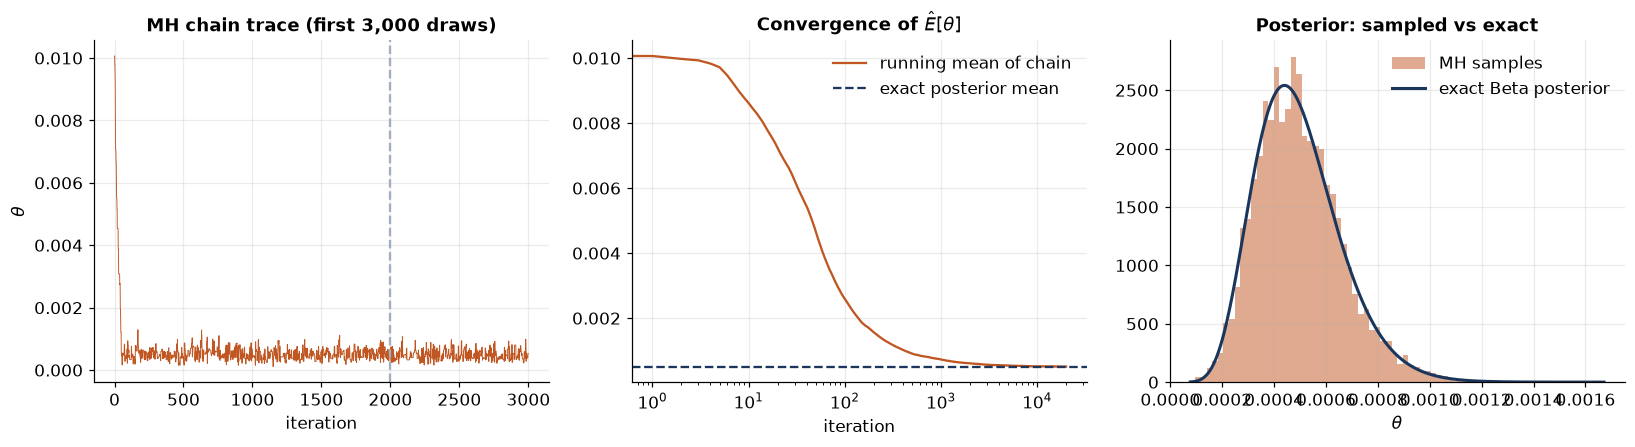

In [5]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

# 1. Trace plot
axes[0].plot(samples[:3000], color=PALETTE["approx"], lw=0.6)
axes[0].axvline(BURN_IN if BURN_IN < 3000 else None, color=PALETTE["muted"], ls="--")
axes[0].set_title("MH chain trace (first 3,000 draws)")
axes[0].set_xlabel("iteration")
axes[0].set_ylabel(r"$\theta$")

# 2. Convergence of the running mean to the exact posterior mean
running_mean = np.cumsum(samples) / np.arange(1, N_ITER + 1)
axes[1].plot(running_mean, color=PALETTE["approx"], label="running mean of chain")
axes[1].axhline(exact_posterior.mean(), color=PALETTE["true"], ls="--",
                 label="exact posterior mean")
axes[1].set_title(r"Convergence of $\hat{E}[\theta]$")
axes[1].set_xlabel("iteration")
axes[1].set_xscale("log")
axes[1].legend()

# 3. Histogram of post-burn-in samples vs exact posterior density
grid = np.linspace(post_burn.min() * 0.8, post_burn.max() * 1.2, 400)
axes[2].hist(post_burn, bins=60, density=True, color=PALETTE["approx"], alpha=0.5,
             label="MH samples")
axes[2].plot(grid, exact_posterior.pdf(grid), color=PALETTE["true"], lw=2,
             label="exact Beta posterior")
axes[2].set_title("Posterior: sampled vs exact")
axes[2].set_xlabel(r"$\theta$")
axes[2].legend()

fig.tight_layout()
save_fig(fig, "mh_diagnostics", NB_DIR)
plt.show()

## Putting it together: a Bayesian estimate of vaccine efficacy

Vaccine efficacy is defined as $VE = 1 - \theta_{\text{vaccine}}/\theta_{\text{placebo}}$.
Because both arms are independent Beta-Bernoulli models, we can run the *same*
Metropolis–Hastings sampler on the placebo arm, and simply combine the two chains
sample-by-sample to get a full posterior distribution over $VE$ — not just a point
estimate, but a Bayesian credible interval, built entirely from the sampler above.

Posterior median vaccine efficacy: 94.6%
95% credible interval:             [90.0%, 97.5%]
Reported trial efficacy (Polack et al. 2020): 95.0%


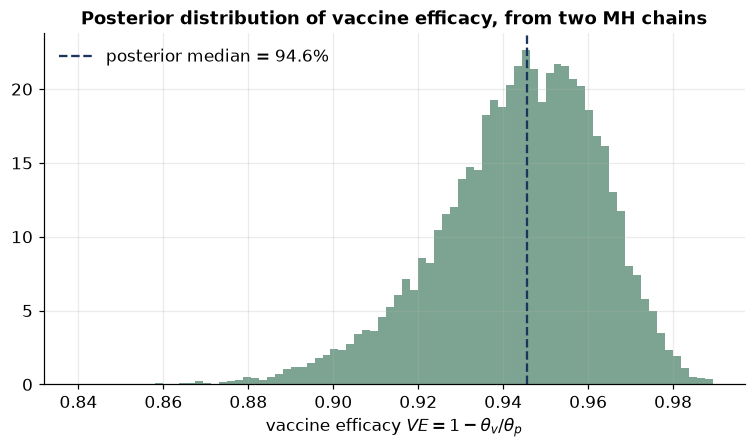

In [6]:
samples_placebo, accept_placebo = metropolis_hastings(
    log_unnormalised_posterior, theta0=0.01, n_iter=N_ITER,
    proposal_sd=PROPOSAL_SD, rng=rng, s=placebo["s"], n=placebo["n"],
)
post_burn_placebo = samples_placebo[BURN_IN:]

ve_samples = 1.0 - post_burn / post_burn_placebo
ve_median = np.median(ve_samples)
ve_low, ve_high = np.percentile(ve_samples, [2.5, 97.5])

print(f"Posterior median vaccine efficacy: {ve_median:.1%}")
print(f"95% credible interval:             [{ve_low:.1%}, {ve_high:.1%}]")
print("Reported trial efficacy (Polack et al. 2020): 95.0%")

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.hist(ve_samples, bins=80, density=True, color=PALETTE["accent"], alpha=0.6)
ax.axvline(ve_median, color=PALETTE["true"], ls="--", label=f"posterior median = {ve_median:.1%}")
ax.set_title("Posterior distribution of vaccine efficacy, from two MH chains")
ax.set_xlabel("vaccine efficacy $VE = 1 - \\theta_v/\\theta_p$")
ax.legend()
fig.tight_layout()
save_fig(fig, "vaccine_efficacy_posterior", NB_DIR)
plt.show()

## Takeaways

- The Metropolis–Hastings sampler recovers the exact Beta posterior mean to several
  decimal places using **only the unnormalised** posterior — exactly the "cancellation
  of normalising constants" property stated in the chapter, demonstrated rather than
  just asserted.
- The same simple sampler, applied twice and combined, turns two real clinical-trial
  arms into a full Bayesian posterior over vaccine efficacy that matches the trial's
  reported ~95% efficacy — the same species of calculation (posterior over a ratio of
  two Beta-distributed rates) used routinely in modern Bayesian A/B testing.
- This is the same conceptual move the chapter traces from Bayes and Laplace through to
  Metropolis, Hastings, Geman & Geman, and Gelfand & Smith: the ability to sample from
  a posterior *without ever normalising it* is what turned Bayesian inference from a
  small set of analytically tractable textbook models into a general computational
  method.